In [34]:
import matplotlib.pyplot as plt
from audio import AudioEngine, SignalGenerator
import numpy as np

In [35]:
TEMPERATURE = 25.0  # celsuis
SAMPLE_RATE = 48000  # hz
EXCITATION_DURATION = 2.0  # excitation signal duration (s)
AMPLITUDE_DB = -50  # excitation signal amplitude (dBFS)
F_START, F_END = (20, 20000)  # excitation signal frequency range (Hz)


In [36]:
#  1. generate signal
signal_gen = SignalGenerator(fs=SAMPLE_RATE, amplitude_db=AMPLITUDE_DB)
signal = signal_gen.generate_sweep(duration=EXCITATION_DURATION, f_start=F_START, f_end=F_END)
#  2. list device
audio_engine = AudioEngine(fs=SAMPLE_RATE)
audio_engine.list_devices()

ID  Name                                     API        In   Out 
----------------------------------------------------------------------
0   BlackHole 2ch                            Core Audio 2    2    *
1   MacBook Air Microphone                   Core Audio 1    0    
2   MacBook Air Speakers                     Core Audio 0    2    
3   Fireface UC Mac (23935003)               Core Audio 18   18   *
4   Aggregate Device                         Core Audio 1    2    *
----------------------------------------------------------------------
Default Input: 3, Default Output: 3


In [37]:
# 3. choose device
input_id = 3 
output_id = 3  
audio_engine.select_device(input_id=input_id, output_id=output_id)

-> Selected input device [3]: Fireface UC Mac (23935003)
-> Selected output device [3]: Fireface UC Mac (23935003)


In [38]:
# 4. measure
record = audio_engine.play_record(signal,output_channel_idx= 3, input_channel_idx=1)

1111-> Measuring... (fs=48000, Input Device=3, Output Device=3)
-> Signal length: 96000 samples, Padded length: 144000 samples


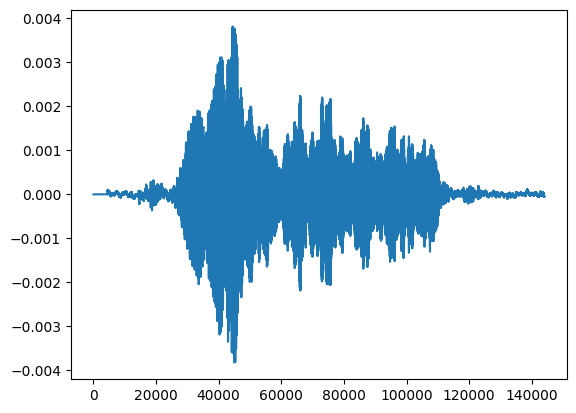

In [39]:
plt.plot(record)
plt.show()

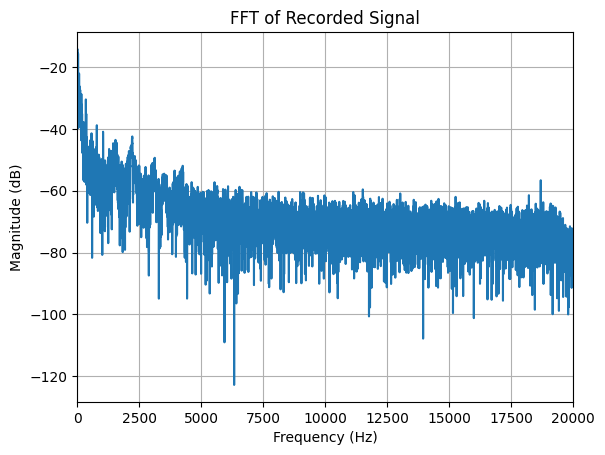

In [40]:
n_fft = 2**14
record_fft = np.fft.rfft(record,n = n_fft, axis=0)
frequencies = np.fft.rfftfreq(n_fft, 1/SAMPLE_RATE)
plt.plot(frequencies, 20*np.log10(np.abs(record_fft[:len(record_fft)])))
plt.xlim(0, 20000)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('FFT of Recorded Signal')
plt.grid()

In [41]:
def deconvolve(signal, record, fs):
    N = len(record)

    # 对齐长度（非常关键）
    signal = np.pad(signal, (0, N - len(signal)))

    # FFT
    X = np.fft.rfft(signal)
    Y = np.fft.rfft(record)

    # 避免除零
    eps = 1e-8
    H = Y / (X + eps)

    # IFFT
    h = np.fft.irfft(H)

    return h

In [ ]:
h = deconvolve(signal, record, SAMPLE_RATE)
time = np.arange(len(h)) / SAMPLE_RATE
plt.plot(time, h)
plt.xlabel('Time (s)')
plt.ylabel('Impulse Response')
plt.title('Estimated Impulse Response')
plt.grid()
plt.show()